In [1]:
import os
import time
import numpy as np
import random
from skimage import io, transform, color, util
import matplotlib.pyplot as plt

# 随机种子
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# 最终数据设置格式
TARGET_SIZE = (32, 32)
DTYPE = np.float32

# 路径（相对路径）
BASE_PATH = '../data'
OUTPUT_PATH = './output'

os.makedirs(OUTPUT_PATH, exist_ok=True)

# 整合数据函数
def skimage_integration_worker(split='train'):
    X, y, meta = [], [], []
    domains = ['mnist', 'svhn', 'usps']
    
    start_time = time.time()
    
    for domain in domains:
        folder_path = os.path.join(BASE_PATH, domain, split)
        files = sorted([f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg'))])
        # print(f"Integrating {domain} [{split}]: {len(files)} samples...")
        
        for filename in files:
            # 标签映射
            label = int(filename.split('_label_')[1].split('.')[0])
            img_path = os.path.join(folder_path, filename)
            
            # Skimage整合
            img = io.imread(img_path)
            orig_size = (img.shape[1], img.shape[0]) # (W, H)
            
            # 统一色彩空间
            if img.ndim == 2:
                # 灰度图转RGB
                img_rgb = color.gray2rgb(img)
            elif img.shape[2] == 4:
                # RGBA转RGB
                img_rgb = color.rgba2rgb(img)
            else:
                img_rgb = img
            
            # 统一尺寸
            # 开启anti_aliasing是skimage的核心优势，用于抑制采样伪影
            img_res = transform.resize(
                img_rgb, 
                TARGET_SIZE, 
                order=1, 
                anti_aliasing=True, 
                preserve_range=False
            )
            
            # 强制转换数据类型
            X.append(img_res.astype(DTYPE))
            y.append(label)
            meta.append({'src': domain, 'orig': orig_size})

    duration = time.time() - start_time
    X_final = np.array(X)
    y_final = np.array(y)
    
    # 保存为npy文件，供下游模型读取
    np.save(f'{OUTPUT_PATH}/X_{split}_ski.npy', X_final)
    np.save(f'{OUTPUT_PATH}/y_{split}_ski.npy', y_final)
    
    return X_final, y_final, meta, duration

# 分别整合train和test
X_train_s, y_train_s, meta_train_s, t_train = skimage_integration_worker('train')
X_test_s, y_test_s, meta_test_s, t_test = skimage_integration_worker('test')

# 常见性能指标输出
total_imgs = len(X_train_s) + len(X_test_s)
total_time = t_train + t_test
print("\n" + "="*35)
print("SKIMAGE INTEGRATION COMPLETE")
print("="*35)
print(f"Total Images:     {total_imgs}")
print(f"Total Time:       {total_time:.4f}s")
print(f"Avg Throughput:   {total_imgs/total_time:.2f} IPS")
print(f"Train Matrix:     {X_train_s.shape} | {X_train_s.nbytes/1e6:.2f} MB")
print(f"Test Matrix:      {X_test_s.shape} | {X_test_s.nbytes/1e6:.2f} MB")
print("="*35)


SKIMAGE INTEGRATION COMPLETE
Total Images:     7500
Total Time:       83.8898s
Avg Throughput:   89.40 IPS
Train Matrix:     (6000, 32, 32, 3) | 73.73 MB
Test Matrix:      (1500, 32, 32, 3) | 18.43 MB


Visualizing Skimage Integrated Training Set Samples...


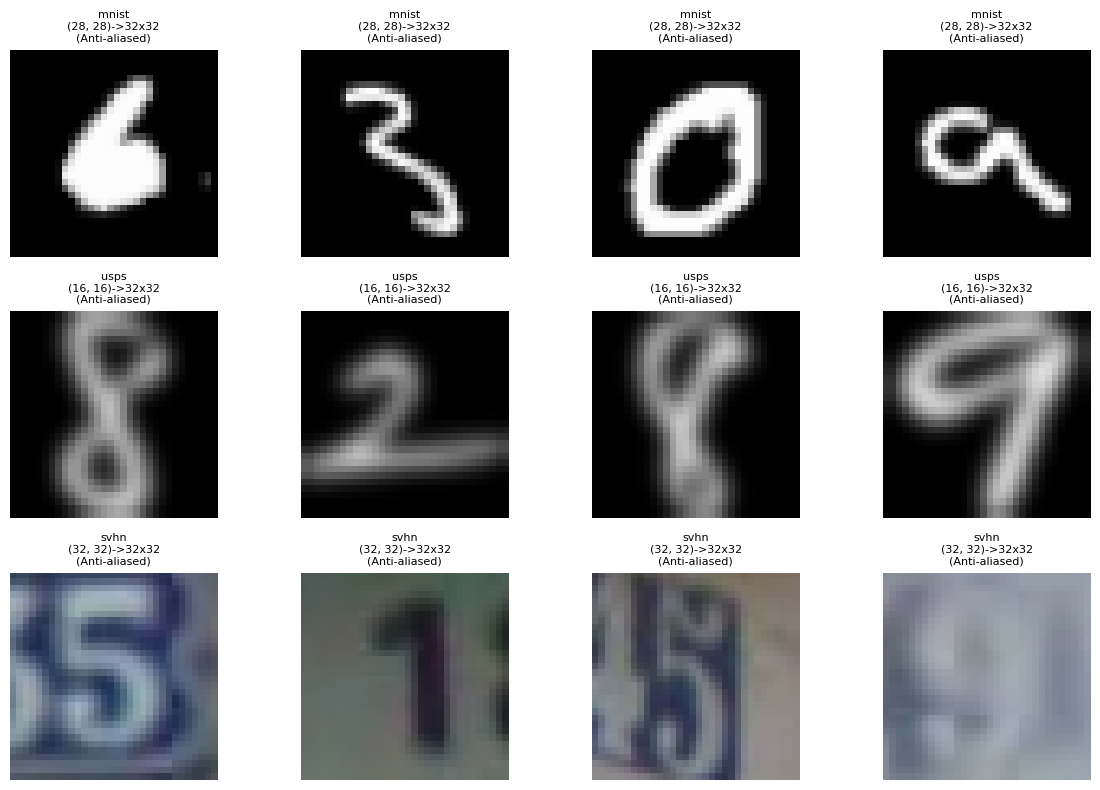

In [3]:
# 挑选部分做可视化，直观感受效果差异
def validate_and_visualize_skimage(X, meta, split_name):
    print(f"Visualizing Skimage Integrated {split_name} Samples...")
    sources = ['mnist', 'usps', 'svhn']
    n_samples = 4
    fig, axes = plt.subplots(len(sources), n_samples, figsize=(12, 8))
    
    for i, src in enumerate(sources):
        # 筛选对应域的索引
        indices = [idx for idx, m in enumerate(meta) if m['src'] == src]
        
        subset = random.sample(indices, n_samples)
        
        for j, idx in enumerate(subset):
            axes[i, j].imshow(X[idx])
            title = f"{src}\n{meta[idx]['orig']}->32x32\n(Anti-aliased)"
            axes[i, j].set_title(title, fontsize=8)
            axes[i, j].axis('off')
            
    plt.tight_layout()
    plt.show()

# 校验训练集整合效果
validate_and_visualize_skimage(X_train_s, meta_train_s, "Training Set")

In [4]:
X_train_ski = np.load(f'{OUTPUT_PATH}/X_train_ski.npy')
X_test_ski = np.load(f'{OUTPUT_PATH}/X_test_ski.npy')

# 做归一化以便进行训练
def standardize_data_ski(train_data, test_data):

    # 计算均值和标准差
    mean = np.mean(train_data)
    std = np.std(train_data)
    
    # Z-Score转换
    X_train_std = (train_data - mean) / std
    X_test_std = (test_data - mean) / std
    
    return X_train_std, X_test_std, mean, std

# 执行标准化
X_train_std_ski, X_test_std_ski, mean_ski, std_ski = standardize_data_ski(X_train_ski, X_test_ski)

# 保存结果
np.save(f'{OUTPUT_PATH}/X_train_std_ski.npy', X_train_std_ski.astype(np.float32))
np.save(f'{OUTPUT_PATH}/X_test_std_ski.npy', X_test_std_ski.astype(np.float32))
np.save(f'{OUTPUT_PATH}/stats_ski.npy', np.array([mean_ski, std_ski]))

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json

# 配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 10
MODEL_SAVE_PATH = f'{OUTPUT_PATH}/cnn_model_ski.pth'

# 设置PyTorch随机种子
torch.manual_seed(RANDOM_SEED)

# 加载数据(N, C, H, W)
x_train_raw_s = np.load(f'{OUTPUT_PATH}/X_train_std_ski.npy')
y_train_raw_s = np.load(f'{OUTPUT_PATH}/y_train_ski.npy')
x_test_raw_s = np.load(f'{OUTPUT_PATH}/X_test_std_ski.npy')
y_test_raw_s = np.load(f'{OUTPUT_PATH}/y_test_ski.npy')

def prepare_loader(x, y):
    # 调整维度: (N, 32, 32, 3) -> (N, 3, 32, 32)
    x_pt = torch.tensor(x.transpose(0, 3, 1, 2), dtype=torch.float32)
    y_pt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(x_pt, y_pt), batch_size=BATCH_SIZE, shuffle=True)

train_loader_s = prepare_loader(x_train_raw_s, y_train_raw_s)
test_loader_s = prepare_loader(x_test_raw_s, y_test_raw_s)

# 定义CNN模型
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 卷积层
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # 全连接层
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x

model_s = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_s.parameters(), lr=LEARNING_RATE)

# 训练
history_s = {'train_loss': [], 'test_acc': []}
print("Starting CNN Training (Skimage Integrated Data)...")

for epoch in range(EPOCHS):
    model_s.train()
    running_loss = 0.0
    for inputs, labels in train_loader_s:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_s(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # 测试集评估
    model_s.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader_s:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_s(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    acc = 100 * correct / total
    history_s['train_loss'].append(running_loss/len(train_loader_s))
    history_s['test_acc'].append(acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(train_loader_s):.4f} | Test Acc: {acc:.2f}%")

# 保存模型与结果分析指标
torch.save(model_s.state_dict(), MODEL_SAVE_PATH)
with open(f'{OUTPUT_PATH}/history_ski.json', 'w') as f:
    json.dump(history_s, f)

print(f"\nModel and metrics saved to {OUTPUT_PATH}")

Starting CNN Training (Skimage Integrated Data)...
Epoch 1/10 | Loss: 1.1721 | Test Acc: 74.87%
Epoch 2/10 | Loss: 0.6161 | Test Acc: 82.73%
Epoch 3/10 | Loss: 0.4565 | Test Acc: 85.73%
Epoch 4/10 | Loss: 0.3228 | Test Acc: 87.27%
Epoch 5/10 | Loss: 0.2500 | Test Acc: 85.87%
Epoch 6/10 | Loss: 0.2131 | Test Acc: 90.00%
Epoch 7/10 | Loss: 0.1590 | Test Acc: 88.07%
Epoch 8/10 | Loss: 0.1377 | Test Acc: 89.00%
Epoch 9/10 | Loss: 0.1103 | Test Acc: 88.27%
Epoch 10/10 | Loss: 0.1066 | Test Acc: 88.60%

Model and metrics saved to ./output
